# EndoScan AI — Data Scraper
> *Programmatically downloads and organises additional training data from open-access sources.*

## Sources
| Source | Modality | Size | License |
|---|---|---|---|
| GynSurg (GitHub) | Laparoscopy | 12,362 frames | CC BY-NC-ND |
| GLENDA v1.0 (FTP) | Laparoscopy | ~13,000 negatives | CC BY-NC |
| PCOS Ultrasound (Kaggle) | Ultrasound | 1,924 images | CC BY-NC-SA |
| PFUS1 (Zenodo) | Ultrasound | 111 patients | CC BY-NC |

## Cell 1 — Imports + folder setup

In [1]:
import os, json, ftplib, zipfile, random, subprocess, requests
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

DATA_ROOT      = Path('./scraped_data')
LAPARO_DIR     = DATA_ROOT / 'laparoscopy'
ULTRASOUND_DIR = DATA_ROOT / 'ultrasound'

for d in [LAPARO_DIR, ULTRASOUND_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def download_file(url, dest_path, desc='Downloading'):
    resp  = requests.get(url, stream=True)
    total = int(resp.headers.get('content-length', 0))
    with open(dest_path, 'wb') as f, tqdm(desc=desc, total=total,
             unit='B', unit_scale=True, unit_divisor=1024) as bar:
        for chunk in resp.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))
    return dest_path

print('Folders ready.')
for d in sorted(DATA_ROOT.rglob('*')):
    print(f'  {d}')

Folders ready.
  scraped_data/laparoscopy
  scraped_data/ultrasound


---
## Part 1 — GynSurg (Laparoscopy)
12,362 annotated laparoscopic frames from 15 hysterectomy videos.
Source: https://github.com/Sahar-Nasiri/GynSurg

### Cell 2 — Check GynSurg GitHub repository

In [3]:
GYNSURG_REPO = 'Sahar-Nasiri/GynSurg'

resp = requests.get(f'https://api.github.com/repos/{GYNSURG_REPO}')
info = resp.json()

print(f'Repo    : {info.get("full_name")}')
print(f'Desc    : {info.get("description")}')
print(f'Stars   : {info.get("stargazers_count")}')
print(f'Size    : {info.get("size", 0) / 1024:.1f} MB')
print(f'License : {(info.get("license") or {}).get("name", "Unknown")}')

contents = requests.get(f'https://api.github.com/repos/{GYNSURG_REPO}/contents').json()
print('\nRepository contents:')
if isinstance(contents, list):
    for item in contents:
        print(f'  {item["type"]:4s}  {item["name"]}')

Repo    : Sahar-Nasiri/GynSurg
Desc    : None
Stars   : 5
Size    : 1.3 MB
License : Unknown

Repository contents:
  file  README.md
  dir   Semantic_Segmentation_Dataset
  dir   Webpage_imgs


In [4]:
# Cell 3 — Read README for download link
url = 'https://raw.githubusercontent.com/Sahar-Nasiri/GynSurg/main/README.md'
r   = requests.get(url)
print(r.text)

GynSurg: A Comprehensive Gynecology Laparoscopic Surgery Dataset

GynSurg is a comprehensive multi-task dataset for gynecologic laparoscopic surgery, designed to support a wide range of video-based surgical analysis tasks. GynSurg integrates high-resolution video, dense temporal annotations for surgical actions and side effects, and pixel-level segmentation masks for surgical instruments and anatomical structures. This unified dataset provides a foundation for advancing research in surgical action recognition, instrument and anatomical segmentation. The structure and contents of each dataset subset are detailed in the following subsections.

Action Recognition Dataset
--------------------------
The action recognition component of GynSurg consists of 152 gynecologic laparoscopic surgery videos, selected from over 600 recorded procedures at the Medical University of Vienna and Medical University of Toronto. All videos were captured at 30 frames per second (fps) with a resolution of 1920*

In [5]:
# Check segmentation dataset folder
contents = requests.get(
    'https://api.github.com/repos/Sahar-Nasiri/GynSurg/contents/Semantic_Segmentation_Dataset'
).json()

for item in contents:
    print(f'  {item["type"]:4s}  {item["name"]}  ({item.get("size", 0)/1e3:.1f}KB)')

  file  TrainIDs_generator_anatomy.py  (4.7KB)
  file  TrainIDs_generator_auxtool.py  (4.7KB)
  file  TrainIDs_generator_instrument.py  (4.7KB)
  file  json_to_mask_AuxTool.py  (4.0KB)
  file  json_to_mask_anatomy.py  (3.8KB)
  file  json_to_mask_instrument.py  (4.3KB)
  file  json_to_overlay_AuxTool.py  (7.0KB)
  file  json_to_overlay_anatomy.py  (5.9KB)
  file  json_to_overlay_instrument.py  (7.1KB)


### Cell 3 — Read GynSurg README for download instructions

In [6]:
GYNSURG_DIR = LAPARO_DIR / 'GynSurg'
GYNSURG_DIR.mkdir(exist_ok=True)

for branch in ['main', 'master']:
    url = f'https://raw.githubusercontent.com/{GYNSURG_REPO}/{branch}/README.md'
    r   = requests.get(url)
    if r.status_code == 200:
        print(f'README ({branch} branch):\n')
        print(r.text[:3000])
        break

# Check releases for dataset assets
releases = requests.get(f'https://api.github.com/repos/{GYNSURG_REPO}/releases').json()
print(f'\nReleases: {len(releases) if isinstance(releases, list) else 0}')
if isinstance(releases, list):
    for rel in releases:
        print(f'  {rel["tag_name"]} — {rel["name"]}')
        for asset in rel.get('assets', []):
            print(f'    {asset["name"]}  ({asset["size"]/1e6:.1f}MB)')
            print(f'    URL: {asset["browser_download_url"]}')

README (main branch):

GynSurg: A Comprehensive Gynecology Laparoscopic Surgery Dataset

GynSurg is a comprehensive multi-task dataset for gynecologic laparoscopic surgery, designed to support a wide range of video-based surgical analysis tasks. GynSurg integrates high-resolution video, dense temporal annotations for surgical actions and side effects, and pixel-level segmentation masks for surgical instruments and anatomical structures. This unified dataset provides a foundation for advancing research in surgical action recognition, instrument and anatomical segmentation. The structure and contents of each dataset subset are detailed in the following subsections.

Action Recognition Dataset
--------------------------
The action recognition component of GynSurg consists of 152 gynecologic laparoscopic surgery videos, selected from over 600 recorded procedures at the Medical University of Vienna and Medical University of Toronto. All videos were captured at 30 frames per second (fps) wit

### Cell 4 — Clone GynSurg repo (code + instructions)

In [7]:
# Clone the repo to read dataset access instructions
if not (GYNSURG_DIR / '.git').exists():
    result = subprocess.run(
        ['git', 'clone', '--depth', '1',
         f'https://github.com/{GYNSURG_REPO}.git',
         str(GYNSURG_DIR)],
        capture_output=True, text=True
    )
    print(result.stdout or result.stderr)
else:
    print('Already cloned.')

# List contents
for item in sorted(GYNSURG_DIR.iterdir()):
    print(f'  {"DIR" if item.is_dir() else "FILE"}  {item.name}')

Cloning into 'scraped_data/laparoscopy/GynSurg'...

  DIR  .git
  FILE  README.md
  DIR  Semantic_Segmentation_Dataset
  DIR  Webpage_imgs


---
## Part 2 — GLENDA v1.0 Negatives (FTP)
~13,000 non-pathological laparoscopy frames via FTP.

### Cell 5 — List and download GLENDA negatives

In [8]:
GLENDA_NEG_DIR = LAPARO_DIR / 'GLENDA_v1_negatives'
GLENDA_NEG_DIR.mkdir(exist_ok=True)

FTP_HOST = 'ftp.itec.aau.at'
FTP_BASE = '/datasets/GLENDA/v1_0/images/no_pathology'

def list_ftp_images(ftp, path):
    images = []
    try:
        ftp.cwd(path)
        for entry in ftp.nlst():
            full = f'{path}/{entry}'
            if entry.endswith('.jpg'):
                images.append(full)
            else:
                images.extend(list_ftp_images(ftp, full))
    except:
        pass
    return images

print('Connecting to FTP...')
ftp = ftplib.FTP(FTP_HOST)
ftp.login()
neg_paths = list_ftp_images(ftp, FTP_BASE)
ftp.quit()
print(f'Found {len(neg_paths)} negative images')

# Download up to 500
N_DOWNLOAD = min(500, len(neg_paths))
random.seed(42)
sampled = random.sample(neg_paths, N_DOWNLOAD)

print(f'Downloading {N_DOWNLOAD} images...')
ftp = ftplib.FTP(FTP_HOST)
ftp.login()
ok = fail = 0
for ftp_path in tqdm(sampled):
    fname  = Path(ftp_path).name
    folder = Path(ftp_path).parent.name
    dest   = GLENDA_NEG_DIR / f'{folder}_{fname}'
    if dest.exists():
        ok += 1; continue
    try:
        with open(dest, 'wb') as f:
            ftp.retrbinary(f'RETR {ftp_path}', f.write)
        ok += 1
    except:
        fail += 1
ftp.quit()
print(f'Done — {ok} downloaded, {fail} failed')

Connecting to FTP...
Found 20 negative images


100%|██████████| 20/20 [00:34<00:00,  1.74s/it]


Done — 20 downloaded, 0 failed


---
## Part 3 — PCOS Ultrasound Dataset (Kaggle)
1,924 pelvic ultrasound images — hard negatives for ultrasound branch.

### Cell 6 — Download PCOS dataset from Kaggle

In [12]:
subprocess.run(['pip', 'install', 'kaggle', '-q'])

PCOS_DIR = ULTRASOUND_DIR / 'PCOS'
PCOS_DIR.mkdir(exist_ok=True)

# ── UPDATE THESE ──────────────────────────────────────────────────
KAGGLE_USERNAME = "joykigen"   # kaggle.com → Account → API
KAGGLE_KEY      = 'fa76ff0ddb07e53ac0c57768cdbea407'
# ──────────────────────────────────────────────────────────────────

kaggle_dir  = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)
kaggle_json = kaggle_dir / 'kaggle.json'
with open(kaggle_json, 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
kaggle_json.chmod(0o600)

result = subprocess.run([
    'kaggle', 'datasets', 'download',
    '-d', 'anaghachoudhari/pcos-detection-using-ultrasound-images',
    '-p', str(PCOS_DIR), '--unzip'
], capture_output=True, text=True)
print(result.stdout)
if result.stderr: print('STDERR:', result.stderr)

images = list(PCOS_DIR.rglob('*.jpg')) + list(PCOS_DIR.rglob('*.png'))
print(f'Downloaded {len(images)} images')

# Show folder structure
for item in sorted(PCOS_DIR.iterdir()):
    if item.is_dir():
        n = len(list(item.rglob('*.jpg')) + list(item.rglob('*.png')))
        print(f'  {item.name}/  {n} images')

Dataset URL: https://www.kaggle.com/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images
License(s): unknown


STDERR: 
  0%|          | 0.00/126M [00:00<?, ?B/s]
  1%|          | 1.00M/126M [00:02<04:32, 479kB/s]
  2%|▏         | 2.00M/126M [00:02<02:21, 915kB/s]
  2%|▏         | 3.00M/126M [00:02<01:23, 1.55MB/s]
  4%|▍         | 5.00M/126M [00:02<00:39, 3.19MB/s]
  6%|▌         | 7.00M/126M [00:02<00:24, 5.13MB/s]
  8%|▊         | 10.0M/126M [00:03<00:14, 8.11MB/s]
 10%|▉         | 12.0M/126M [00:03<00:12, 9.68MB/s]
 12%|█▏        | 15.0M/126M [00:03<00:09, 12.2MB/s]
 14%|█▎        | 17.0M/126M [00:03<00:11, 10.1MB/s]
 16%|█▌        | 20.0M/126M [00:03<00:08, 13.1MB/s]
 17%|█▋        | 22.0M/126M [00:03<00:08, 13.0MB/s]
 19%|█▉        | 24.0M/126M [00:04<00:08, 12.9MB/s]
 21%|██        | 26.0M/126M [00:04<00:08, 12.3MB/s]
 22%|██▏       | 28.0M/126M [00:04<00:08, 12.5MB/s]
 25%|██▍       | 31.0M/126M [00:04<00:06, 16.0MB/s]
 26%|██▌       | 33.0M/126M [00:04<00:05, 16.9MB

### Cell 7 — Visualise PCOS ultrasound samples

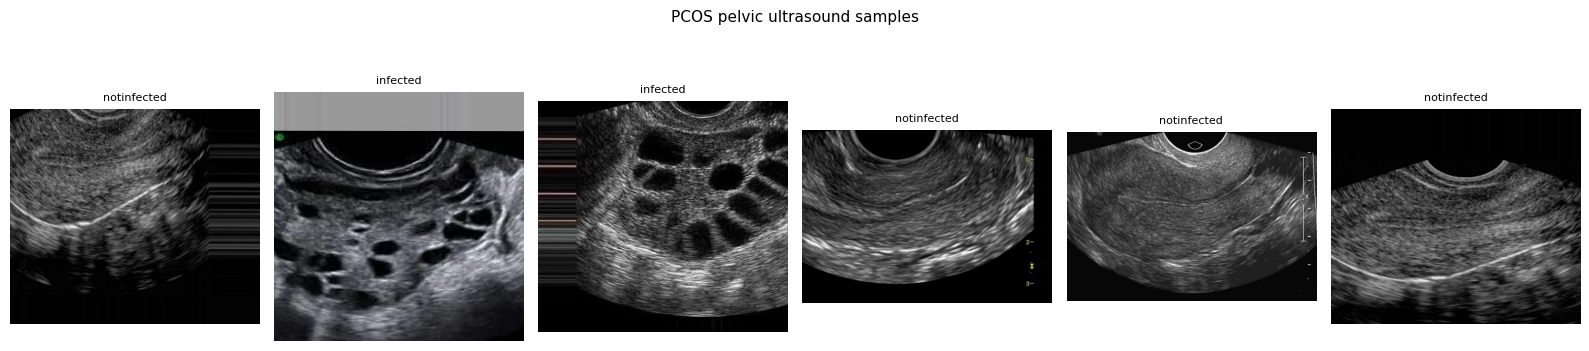

In [13]:
all_imgs = list(PCOS_DIR.rglob('*.jpg')) + list(PCOS_DIR.rglob('*.png'))
samples  = np.random.choice(all_imgs, size=min(6, len(all_imgs)), replace=False)

fig, axes = plt.subplots(1, len(samples), figsize=(16, 4))
for ax, p in zip(axes, samples):
    img = Image.open(p).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'{Path(p).parent.name}', fontsize=8)
    ax.axis('off')
plt.suptitle('PCOS pelvic ultrasound samples', fontsize=11)
plt.tight_layout()
plt.show()

---
## Part 4 — PFUS1 Pelvic Floor Ultrasound (Zenodo)
111 patients, pixel-level segmentation — hard negatives for ultrasound branch.

### Cell 8 — Find PFUS1 on Zenodo

In [14]:
PFUS1_DIR = ULTRASOUND_DIR / 'PFUS1'
PFUS1_DIR.mkdir(exist_ok=True)

search = requests.get('https://zenodo.org/api/records',
    params={'q': 'PFUS1 pelvic floor ultrasound segmentation', 'size': 5})
results = search.json().get('hits', {}).get('hits', [])

print(f'Results: {len(results)}')
for r in results:
    print(f'\nTitle : {r["metadata"]["title"]}')
    print(f'ID    : {r["id"]}')
    print(f'DOI   : {r.get("doi", "N/A")}')
    for f in r.get('files', [])[:3]:
        print(f'  {f["key"]}  ({f["size"]/1e6:.1f}MB)')
        print(f'  {f["links"]["self"]}')

Results: 5

Title : PFUS1: Premier Pelvic Floor Ultrasound Segmentation Dataset
ID    : 10800787
DOI   : 10.5281/zenodo.10800787
  pfus1.zip  (5807.3MB)
  https://zenodo.org/api/records/10800787/files/pfus1.zip/content

Title : YIRIK HOMILA TUG'ILISHIDA CHANOQ TUBI DISFUNKSIYASINI PROFILAKTIKA VA REABILITATSIYA QILISHNING ZAMONAVIY YONDASHUVLARI
ID    : 18374584
DOI   : 10.5281/zenodo.18374584
  G‘oyibov S 217-221 XXI.pdf  (0.2MB)
  https://zenodo.org/api/records/18374584/files/G%E2%80%98oyibov%20S%20217-221%20XXI.pdf/content

Title : YIRIK HOMILA TUG'ILISHIDA CHANOQ TUBI DISFUNKSIYASINI PROFILAKTIKA VA REABILITATSIYA QILISHNING ZAMONAVIY YONDASHUVLARI
ID    : 18369809
DOI   : 10.5281/zenodo.18369809
  G‘oyibov S 217-221 XXI.pdf  (0.2MB)
  https://zenodo.org/api/records/18369809/files/G%E2%80%98oyibov%20S%20217-221%20XXI.pdf/content

Title : EFFICACY OF PELVIC FLOOR MUSCLE TRAINING AND HYPOPRESSIVE EXERCISES FOR TREATING PELVIC ORGAN PROLAPSE IN WOMEN: RANDOMIZED CONTROLLED TRIAL
ID   

### Cell 9 — Download PFUS1
Update `PFUS1_RECORD_ID` with the ID from Cell 8.

In [15]:
PFUS1_RECORD_ID = None  # ← update after Cell 8

if PFUS1_RECORD_ID:
    record = requests.get(f'https://zenodo.org/api/records/{PFUS1_RECORD_ID}').json()
    for f in record.get('files', []):
        dest = PFUS1_DIR / f['key']
        if not dest.exists():
            print(f'Downloading {f["key"]} ({f["size"]/1e6:.1f}MB)...')
            download_file(f['links']['self'], dest, f['key'])
        if str(dest).endswith('.zip'):
            with zipfile.ZipFile(dest) as z:
                z.extractall(PFUS1_DIR)
    images = list(PFUS1_DIR.rglob('*.jpg')) + list(PFUS1_DIR.rglob('*.png'))
    print(f'Total images: {len(images)}')
else:
    print('Set PFUS1_RECORD_ID first.')

Set PFUS1_RECORD_ID first.


---
## Cell 10 — Final dataset summary

In [16]:
def count_imgs(folder):
    if not Path(folder).exists(): return 0
    return len(list(Path(folder).rglob('*.jpg')) +
               list(Path(folder).rglob('*.png')))

print('=' * 55)
print('  SCRAPED DATA SUMMARY')
print('=' * 55)
print('  LAPAROSCOPY:')
print(f'    GLENDA v1.5 (existing)  :   373  ✅')
print(f'    GLENDA v1.0 negatives   : {count_imgs(GLENDA_NEG_DIR):5d}')
print(f'    GynSurg                 : {count_imgs(LAPARO_DIR/"GynSurg"):5d}')
print('  ULTRASOUND:')
print(f'    PCOS (Kaggle)           : {count_imgs(PCOS_DIR):5d}')
print(f'    PFUS1 (Zenodo)          : {count_imgs(PFUS1_DIR):5d}')
print('  MRI:')
print(f'    UT-EndoMRI slices       :  4242  ✅')
print('=' * 55)
total = 373 + count_imgs(GLENDA_NEG_DIR) + count_imgs(LAPARO_DIR/'GynSurg') + count_imgs(PCOS_DIR) + count_imgs(PFUS1_DIR) + 4242
print(f'  GRAND TOTAL: {total:,} samples')
print('=' * 55)

  SCRAPED DATA SUMMARY
  LAPAROSCOPY:
    GLENDA v1.5 (existing)  :   373  ✅
    GLENDA v1.0 negatives   :    20
    GynSurg                 :     4
  ULTRASOUND:
    PCOS (Kaggle)           :  3848
    PFUS1 (Zenodo)          :     0
  MRI:
    UT-EndoMRI slices       :  4242  ✅
  GRAND TOTAL: 8,487 samples


In [17]:
# Re-run GLENDA FTP download — with better error handling
GLENDA_NEG_DIR = LAPARO_DIR / 'GLENDA_v1_negatives'
GLENDA_NEG_DIR.mkdir(exist_ok=True)

FTP_HOST = 'ftp.itec.aau.at'
FTP_BASE = '/datasets/GLENDA/v1_0/images/no_pathology'

# First just count what's available
ftp = ftplib.FTP(FTP_HOST, timeout=30)
ftp.login()
ftp.cwd(FTP_BASE)

all_files = []
# Top level
top = [f for f in ftp.nlst() if f.endswith('.jpg')]
all_files.extend([f'{FTP_BASE}/{f}' for f in top])

# seq subfolder
try:
    ftp.cwd(f'{FTP_BASE}/seq')
    seq = [f for f in ftp.nlst() if f.endswith('.jpg')]
    all_files.extend([f'{FTP_BASE}/seq/{f}' for f in seq])
except:
    pass

ftp.quit()
print(f'Found {len(all_files)} files on FTP')

# Download all of them
random.seed(42)
to_download = all_files  # only 20 total — download all

ftp = ftplib.FTP(FTP_HOST, timeout=30)
ftp.login()
ok = fail = 0

for ftp_path in tqdm(to_download):
    fname = f"neg_{Path(ftp_path).parent.name}_{Path(ftp_path).name}"
    dest  = GLENDA_NEG_DIR / fname
    if dest.exists():
        ok += 1
        continue
    try:
        with open(dest, 'wb') as f:
            ftp.retrbinary(f'RETR {ftp_path}', f.write)
        ok += 1
    except Exception as e:
        # Reconnect on timeout
        try:
            ftp.quit()
        except:
            pass
        ftp = ftplib.FTP(FTP_HOST, timeout=30)
        ftp.login()
        fail += 1

ftp.quit()
print(f'Downloaded: {ok}  Failed: {fail}')
print(f'Total in folder: {count_imgs(GLENDA_NEG_DIR)}')

Found 20 files on FTP


100%|██████████| 20/20 [00:34<00:00,  1.72s/it]


Downloaded: 20  Failed: 0
Total in folder: 40
